## 패키지 선언

In [ ]:
import torch
import torch.nn as nn
import torchvision.datasets as dataset
import torchvision.transforms as transform
from torch.utils.data import DataLoader

## Dataset 선언

In [ ]:
# Training dataset 다운로드
mnist_train = dataset.MNIST(root = "./", # 데이터셋을 저장할 위치
                            train = True,
                            transform = transform.ToTensor(),
                            download = True)
# Testing dataset 다운로드
mnist_test = dataset.MNIST(root = "./",
                            train = False,
                            transform = transform.ToTensor(),
                            download = True)

## MNIST 데이터셋 형상 확인

60000
300
torch.Size([1, 28, 28])
5


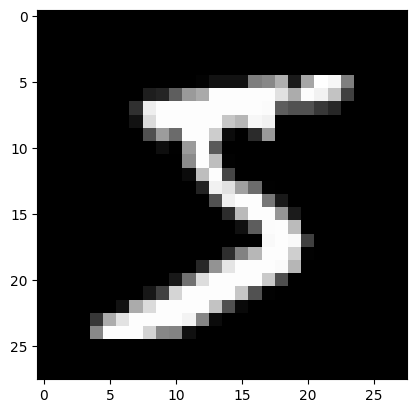

In [ ]:
import matplotlib.pyplot as plt
print(len(mnist_train))     # training dataset 개수 확인

mnist_train.data = mnist_train.data[:300] # 이미지 데이터 개수 300으로 설정
mnist_train.targets = mnist_train.targets[:300] # 라벨 데이터 개수 300으로 설정
print(len(mnist_train))

first_data = mnist_train[0]
print(first_data[0].shape)  # 첫번째 data의 형상 확인
print(first_data[1])        # 첫번째 data의 정답 확인

plt.imshow(first_data[0][0,:,:], cmap='gray')
plt.show()

In [ ]:
first_img = first_data[0]
print(first_img.shape)

first_img = first_img.view(-1, 28*28) # 이미지 평탄화 수행 2D -> 1D
print(first_img.shape)

torch.Size([1, 28, 28])
torch.Size([1, 784])


## Multi Layer Perceptron 모델 정의: 5-layer

In [ ]:
class FMLP (nn.Module):
  def __init__(self):
    super(FMLP, self).__init__()
    self.fc1 = nn.Linear(784, 100)
    self.fc2 = nn.Linear(100, 100)
    self.fc3 = nn.Linear(100, 100)
    self.fc4 = nn.Linear(100, 100)
    self.fc5 = nn.Linear(100, 10)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(0.2) # Dropout 선언(0.2비율)

  def forward(self, x):
    x = x.view(-1, 28*28)

    y = self.relu(self.fc1(x))
    y = self.dropout(y)
    y = self.relu(self.fc2(y))
    y = self.dropout(y)
    y = self.relu(self.fc3(y))
    y = self.dropout(y)
    y = self.relu(self.fc4(y))
    y = self.dropout(y)
    y = self.fc5(y)
    return y

## Hyper-parameters 지정

In [ ]:
batch_size = 10
learning_rate = 0.1
training_epochs = 100 # 에폭 100으로 설정
loss_function = nn.CrossEntropyLoss()
network = FMLP()
optimizer = torch.optim.SGD(network.parameters(), lr = learning_rate)

data_loader = DataLoader(dataset=mnist_train,
                         batch_size=batch_size,
                         shuffle=True,
                         drop_last=True)

## Perceptron 학습을 위한 반복문 선언

In [ ]:
for epoch in range(training_epochs):
  avg_cost = 0
  total_batch = len(data_loader)

  for img, label in data_loader:

    pred = network(img)

    loss = loss_function(pred, label)
    optimizer.zero_grad() # gradient 초기화
    loss.backward()
    optimizer.step()

    avg_cost += loss / total_batch

  print('Epoch: %d Loss = %f'%(epoch+1, avg_cost))

print('Learning finished')

Epoch: 1 Loss = 2.304979
Epoch: 2 Loss = 2.295087
Epoch: 3 Loss = 2.287106
Epoch: 4 Loss = 2.276269
Epoch: 5 Loss = 2.252068
Epoch: 6 Loss = 2.175312
Epoch: 7 Loss = 1.969933
Epoch: 8 Loss = 1.723593
Epoch: 9 Loss = 1.442961
Epoch: 10 Loss = 1.311889
Epoch: 11 Loss = 1.108426
Epoch: 12 Loss = 1.005940
Epoch: 13 Loss = 0.774985
Epoch: 14 Loss = 0.780957
Epoch: 15 Loss = 0.583606
Epoch: 16 Loss = 0.568479
Epoch: 17 Loss = 0.435878
Epoch: 18 Loss = 0.480411
Epoch: 19 Loss = 0.321016
Epoch: 20 Loss = 0.407120
Epoch: 21 Loss = 0.336412
Epoch: 22 Loss = 0.186582
Epoch: 23 Loss = 0.167565
Epoch: 24 Loss = 0.154756
Epoch: 25 Loss = 0.318532
Epoch: 26 Loss = 0.353495
Epoch: 27 Loss = 0.144947
Epoch: 28 Loss = 0.106056
Epoch: 29 Loss = 0.107180
Epoch: 30 Loss = 0.113792
Epoch: 31 Loss = 0.081260
Epoch: 32 Loss = 0.036356
Epoch: 33 Loss = 0.089850
Epoch: 34 Loss = 0.025623
Epoch: 35 Loss = 0.168300
Epoch: 36 Loss = 0.037223
Epoch: 37 Loss = 0.088371
Epoch: 38 Loss = 0.356249
Epoch: 39 Loss = 0.12

## Train Data 적용

In [ ]:
with torch.no_grad():
  network.eval()
  img_test = mnist_train.data.float()
  label_test = mnist_train.targets
  prediction = network(img_test)

  correct_prediction = torch.argmax(prediction, 1) == label_test
  accuracy = correct_prediction.float().mean()
  print('Accuracy:', accuracy.item())

Accuracy: 1.0


##Test Data 적용

In [ ]:
with torch.no_grad():
  network.eval() # Network Dropout 비활성
  img_test = mnist_test.data.float()
  label_test = mnist_test.targets

  prediction = network(img_test) # 전체 test data를 한번에 계산

  correct_prediction = torch.argmax(prediction, 1) == label_test
  accuracy = correct_prediction.float().mean()
  print('Accuracy:', accuracy.item()) # overfitting 문제일 경우 정답률 77% 부근   # Batch Normalization으로 해결했을 경우 정답률 80% 부근
  # dropout으로 해결했을 경우 정답률 80% 부근

Accuracy: 0.7943999767303467


## Weight parameter 저장하기/불러오기

In [ ]:
torch.save(network.state_dict(), "./mlp_mnist.pth")